<a href="https://colab.research.google.com/github/useDeep/learn_pytorch/blob/main/02_pytorch_classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
torch.__version__

'2.10.0+cpu'

In [2]:
from sklearn.datasets import make_circles

In [3]:
# Create circles

n_samples= 1000

X, y= make_circles(n_samples, noise= 0.03, random_state= 42)

In [4]:
len(X), len(y)

(1000, 1000)

In [5]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of y: {y[:5]}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: [1 1 1 1 0]


In [6]:
# Make Dataframe of circle data

circles= pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "label": y})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


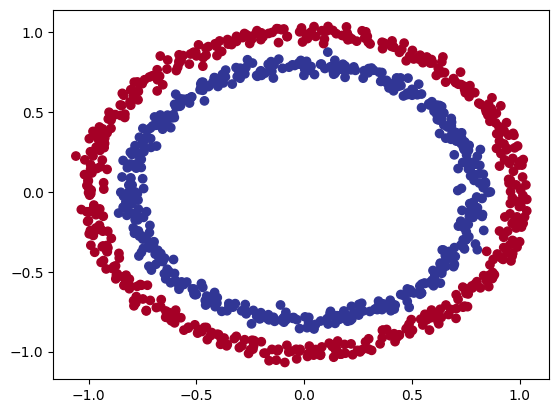

In [7]:
plt.scatter(x=X[:, 0], y= X[:, 1], c= y, cmap= plt.cm.RdYlBu)

### 1.1 Check input and output shapes

In [8]:
X.shape, y.shape

((1000, 2), (1000,))

In [9]:
# View the first example of features and labels
X_sample= X[0]
y_sample= y[0]

print(f"Value for one sample of X: {X_sample} and the value of one sample of y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the shape of one sample of y: {y_sample.shape}")

Value for one sample of X: [0.75424625 0.23148074] and the value of one sample of y: 1
Shapes for one sample of X: (2,) and the shape of one sample of y: ()


In [10]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

### 1.2 Turn data into tensors and create train and test splits

In [11]:
# Turn data into tensors
X= torch.from_numpy(X).type(torch.float)
y= torch.from_numpy(y).type(torch.float)

type(X)

torch.Tensor

In [12]:
# Split data inot training and test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 7)


In [13]:
len(X_train), len(X_test)

(800, 200)

## 2. Building a model to classify between blue and red dots

In [14]:
from torch import nn

# setup device agnostic code
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Creating model:

1. Subclasses `nn.Module` (almost all models in pytorch subclass `nn.Module`)
2. Create 2 `nn.linear()` layers that are capable of handling the shapes of our data
3. Define a `forward()` method that outlines the forward pass (or forward computation) of the model
4. Instantiate an instance of our model class and send it to the target `device`

In [15]:
# 1. Construct model that subclasses nn.Module
class CircleModelV0(nn.Module):
  def __intit__(self):
    super().__intit__()
    # 2. Create 2 nn.linear() layers that are capable of handling the shapes of our data
    self.layer_1= nn.Linear(in_features=2, out_features=5)
    self.layer_2= nn.Linear(in_features= 5, out_features= 1)

  # 3. Define a forward() method that outlines the forward pass (or forward computation) of the model
  def forward(self, x):
    return self.layer_2(self.layer_1(x))    # x -> layer1 -> layer2 -> output


# 4. Instantiate an instance of our model class and send it to the target device
model_0= CircleModelV0().to(device)
model_0

CircleModelV0()

In [16]:
# Replicate the above model using nn.Sequential()
model_0= nn.Sequential(nn.Linear(in_features= 2, out_features=5), nn.Linear(in_features=5, out_features=1)).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
# Predictions
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.2677, -0.0499],
                      [ 0.1295, -0.4317],
                      [ 0.3755,  0.1047],
                      [ 0.1738,  0.3162],
                      [-0.4290, -0.2520]])),
             ('0.bias', tensor([0.5322, 0.1779, 0.0452, 0.3768, 0.2892])),
             ('1.weight',
              tensor([[-0.2452,  0.3817, -0.4325, -0.1575,  0.2944]])),
             ('1.bias', tensor([-0.1426]))])

In [18]:
# Predictions
with torch.inference_mode():
  untrained_preds= model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])


In [19]:
print(f"First 10 predictions: \n {untrained_preds[: 10]}")
print(f"First 10 labels: \n {y_test[: 10]}")

First 10 predictions: 
 tensor([[ 0.1916],
        [-0.5294],
        [-0.5511],
        [-0.5583],
        [-0.3093],
        [-0.6454],
        [-0.3383],
        [ 0.1478],
        [ 0.2439],
        [ 0.1877]])
First 10 labels: 
 tensor([0., 0., 0., 1., 1., 0., 1., 1., 0., 0.])


### 2.1 Setup loss function and optimiser

Regression: MAE or MSE (mean absolute error or mean squared error), etc
Classificaion: Binary cross entropy or categorical cross entropy (cross entropy), etc

And for optimisers, two of the most common are SGD and Adam, however pytorch has many built-in options

In [20]:
# Setup loss function
# loss_fn= nn.BCELoss()   BCELoss requires inputs to have gone through the sigmoid activation function prior to input to BCELoss
loss_fn= nn.BCEWithLogitsLoss()     # nn.BCEWithLogitsLoss() has sigmoid activation function built in (sigmoid layer + BCE loss) -> nn.Sequential(nn.sigmoid(), nn.BCELoss())

In [21]:
optimizer= torch.optim.SGD(params=model_0.parameters(), lr= 0.1)

In [22]:
# Calculate accuracy (percentage of correct predictions)

def accuracy_fn(y_true, y_pred):
  correct= torch.eq(y_true, y_pred).sum().item()
  acc= (correct/ len(y_pred)) * 100
  return acc

## 3. Train model

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (gradient descent)

### 3.1 Going from raw logite -> predition probability -> prediction labels

Model outputs are raw, unnormalized **logits**.

Concert these logits into prediction probabilities by passing them to some kind of activation function (e.g. Sigmoid for binary cross entropy and softmax for multiclass classification)

Then convert model's prediction probabilities to prediction labels by either rounding the or taking the `argmax()`

In [23]:
# View the 5 first outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits= model_0(X_test.to(device))[:5]
y_logits

tensor([[ 0.1916],
        [-0.5294],
        [-0.5511],
        [-0.5583],
        [-0.3093]])

In [24]:
# sigmoid activation function on the logits teo turn them into prediction probabilites
y_pred_probs= torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5477],
        [0.3707],
        [0.3656],
        [0.3639],
        [0.4233]])

For the prediction probability values, we need to perform a range-style rounding on them:
- `y_pred_probs` >= 0.5, `y= 1` (class= 1)
- `y_pred_probs` < 0.5, `y= 0` (class= 0)

In [25]:
# Find the predicted labels
y_preds= torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
y_pred_labels= torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([1., 0., 0., 0., 0.])

### 3.2 Building a training and test looop

In [26]:
# manual seed
torch.manual_seed(77)

# no. of epochs
epochs= 100

# put the data to target device
X_train, y_train= X_train.to(device), y_train.to(device)
X_test, y_test= X_test.to(device), y_test.to(device)

# build training and evaluation loop
for epoch in range(epochs):
  # Training
  model_0.train()

  # 1. Forward pass
  y_logits= model_0(X_train).squeeze()
  y_pred= torch.round(torch.sigmoid(y_logits))    # logits -> pred prob -> pred labels

  # 2. Calculate loss/ accuracy
  loss = loss_fn(y_logits, y_pred)    # nn.BCEWithLogitsLoss() expects raw logits and prediction probabilites as input
  # loss= loss_fn(torch.sigmoid(y_logits), y_train)   # if n.BCELoss, expects prediction probabilites as input

  acc= accuracy_fn(y_true= y_train, y_pred= y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)

  # 5. Optimizer step (gradient descent)
  optimizer.step()

  # Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits= model_0(X_test).squeeze()
    test_pred= torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss/ accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_acc= accuracy_fn(y_true= y_test, y_pred= test_pred)

  # print values
  if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.56198, Acc: 47.88% | Test loss: 0.70836, Test acc: 48.00%
Epoch: 10 | Loss: 0.56198, Acc: 47.88% | Test loss: 0.70836, Test acc: 48.00%
Epoch: 20 | Loss: 0.56198, Acc: 47.88% | Test loss: 0.70836, Test acc: 48.00%
Epoch: 30 | Loss: 0.56198, Acc: 47.88% | Test loss: 0.70836, Test acc: 48.00%
Epoch: 40 | Loss: 0.56198, Acc: 47.88% | Test loss: 0.70836, Test acc: 48.00%
Epoch: 50 | Loss: 0.56198, Acc: 47.88% | Test loss: 0.70836, Test acc: 48.00%
Epoch: 60 | Loss: 0.56198, Acc: 47.88% | Test loss: 0.70836, Test acc: 48.00%
Epoch: 70 | Loss: 0.56198, Acc: 47.88% | Test loss: 0.70836, Test acc: 48.00%
Epoch: 80 | Loss: 0.56198, Acc: 47.88% | Test loss: 0.70836, Test acc: 48.00%
Epoch: 90 | Loss: 0.56198, Acc: 47.88% | Test loss: 0.70836, Test acc: 48.00%


In [27]:
print(torch.manual_seed)

<function manual_seed at 0x7887687a3560>


In [28]:
import requests
from pathlib import Path

# Download helper functon from the repo
if Path('helper_functions.py').is_file():
  print("Helper functions file already exists")
else:
  print("Downloading helper_functions.py file")
  request= requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

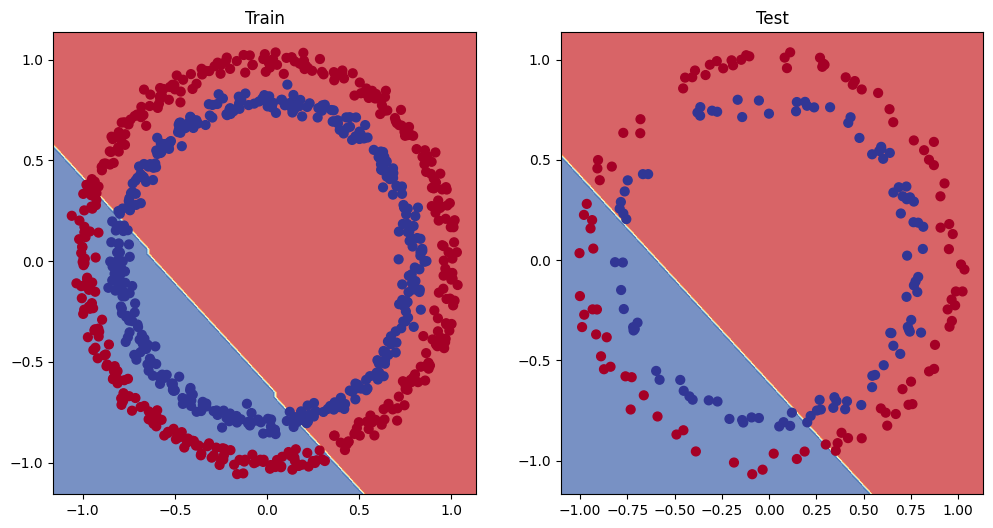

In [29]:
from helper_functions import plot_predictions, plot_decision_boundary

# plot decision boundary of the model
plt.figure(figsize= (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

# 5. Improving a model (from a model perspective)

Let's try to fix our model's underfitting problem.

Focusing specifically on the model (not the data), there are a few ways we could do this.

1. Add more layers ->	Each layer potentially increases the learning capabilities of the model with each layer being able to learn some kind of new pattern in the data. More layers are often referred to as making your neural network deeper.
2. Add more hidden units ->	Similar to the above, more hidden units per layer means a potential increase in learning capabilities of the model. More hidden units are often referred to as making your neural network wider.
3. Fitting for longer (more epochs) ->	Your model might learn more if it had more opportunities to look at the data.
4. Changing the activation functions ->	Some data just can't be fit with only straight lines (like what we've seen), using non-linear activation functions can help with this (hint, hint).
5. Change the learning rate ->	Less model specific, but still related, the learning rate of the optimizer decides how much a model should change its parameters each step, too much and the model overcorrects, too little and it doesn't learn enough.
6. Change the loss function ->	Again, less model specific but still important, different problems require different loss functions. For example, a binary cross entropy loss function won't work with a multi-class classification problem.
7. Use transfer learning ->	Take a pretrained model from a problem domain similar to yours and adjust it to your own problem. We cover transfer learning in notebook 06.

    ***Note***: because you can adjust all of these by hand, they're referred to as **hyperparameters**.



Let's try and improve the model by:
- Adding more hidden units: 5 -> 10
- Increase the number of layers: 2 -> 3
- Increase the number of epochs: 100 -> 1000

In [30]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1= nn.Linear(in_features=2, out_features= 10)
    self.layer2= nn.Linear(in_features= 10, out_features= 10)
    self.layer3= nn.Linear(in_features= 10, out_features= 1)

  def forward(self, x):
    # z= self.layer1(x)
    # z= self.layer2(z)
    # z= self.layer3(z)
    # return z
    return self.layer3(self.layer2(self.layer1(x)))

model_1= CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [31]:
model_1.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-2.9428e-01, -3.0309e-01],
                      [-1.3849e-01, -5.0240e-02],
                      [ 6.3686e-01, -3.4447e-01],
                      [ 2.3268e-01,  5.1038e-01],
                      [-2.0675e-01, -2.3379e-01],
                      [ 3.2318e-01,  1.1231e-01],
                      [-7.5814e-03,  6.8318e-01],
                      [ 1.8895e-02, -3.4226e-01],
                      [ 2.9048e-04,  1.6286e-01],
                      [ 1.8140e-01,  2.7892e-01]])),
             ('layer1.bias',
              tensor([ 0.0593,  0.0920, -0.5811,  0.4930, -0.4383, -0.2779,  0.2138, -0.1333,
                       0.4463,  0.2480])),
             ('layer2.weight',
              tensor([[ 0.2786,  0.0947,  0.0841,  0.0702, -0.1994,  0.0447,  0.1093, -0.0644,
                       -0.1651, -0.1844],
                      [ 0.1848, -0.2155,  0.3152, -0.0253,  0.0889,  0.2167,  0.2363,  0.0954,
                       -0.2526,  0.00

In [32]:
# Create a loss function
loss_fn= nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer= torch.optim.SGD(params= model_1.parameters(), lr= 0.1)

In [33]:
# Training and evaluation loop for model_1
torch.manual_seed(77)

epochs= 1000

# Put the data on the target device
X_train, y_tain= X_train.to(device), y_train.to(device)
X_test, y_test= X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  # Training
  model_1.train()
  # 1. Forward pass
  y_logits= model_1(X_train).squeeze()
  y_pred= torch.round(torch.sigmoid(y_logits))  # logists -> pred prob -> pred labels

  # 2. Calculate loss/ accuracy
  loss= loss_fn(y_logits, y_train)
  acc= accuracy_fn(y_true=y_train, y_pred= y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backwards (backpropagation)
  loss.backward()

  # 5. Optimzer step (gradient descent)
  optimizer.step()


  # Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits= model_1(X_test).squeeze()
    test_pred= torch.round(torch.sigmoid(test_logits))

    # 2. calculate the loss
    test_loss= loss_fn(test_logits, y_test)
    test_acc= accuracy_fn(y_true= y_test, y_pred= test_pred)


  # print the details
  if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69397, Acc: 50.12% | Test loss: 0.69347, Test acc: 49.50%
Epoch: 100 | Loss: 0.69309, Acc: 51.75% | Test loss: 0.69376, Test acc: 49.00%
Epoch: 200 | Loss: 0.69289, Acc: 52.12% | Test loss: 0.69468, Test acc: 44.00%
Epoch: 300 | Loss: 0.69282, Acc: 52.38% | Test loss: 0.69531, Test acc: 43.50%
Epoch: 400 | Loss: 0.69279, Acc: 51.88% | Test loss: 0.69572, Test acc: 43.00%
Epoch: 500 | Loss: 0.69278, Acc: 51.75% | Test loss: 0.69598, Test acc: 43.50%
Epoch: 600 | Loss: 0.69278, Acc: 51.50% | Test loss: 0.69614, Test acc: 43.50%
Epoch: 700 | Loss: 0.69278, Acc: 51.50% | Test loss: 0.69624, Test acc: 43.50%
Epoch: 800 | Loss: 0.69278, Acc: 51.88% | Test loss: 0.69629, Test acc: 43.50%
Epoch: 900 | Loss: 0.69278, Acc: 51.75% | Test loss: 0.69633, Test acc: 43.50%


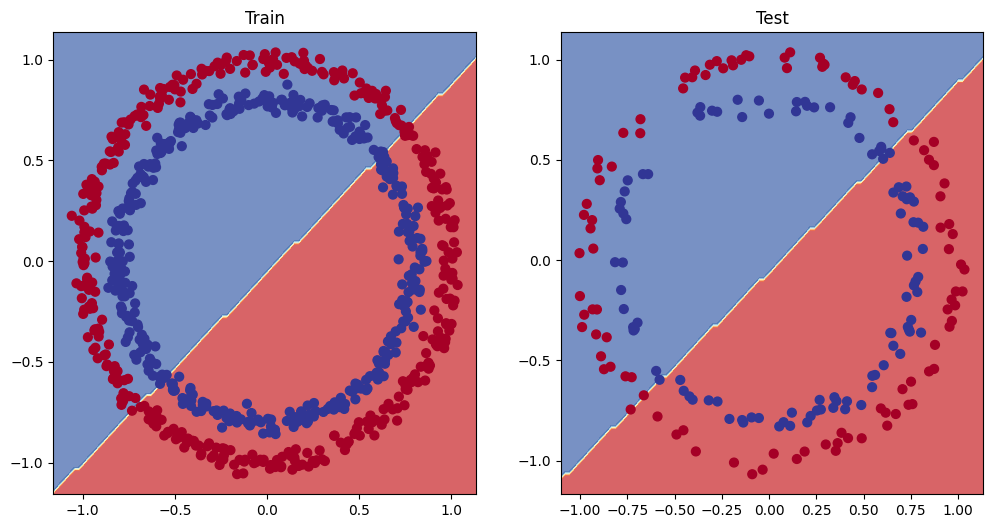

In [34]:
from helper_functions import plot_predictions, plot_decision_boundary

# plot decision boundary of the model
plt.figure(figsize= (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

 ### 5.1 Preparing data to see if our model can fit a straight line

 One way to troubleshoot a larger problem is to test out a smaller problem

In [35]:
# Create some data (same as chapter 1)
weight= 0.7
bias= 0.3
start= 0
end= 1
step= 0.01

# Create data
X_regression= torch.arange(start, end, step).unsqueeze(dim= 1)
y_regression= weight * X_regression + bias # Linear regression formula (without epsi)

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [36]:
# Create train and testg splits
train_split= int(0.8* len(X_regression))
X_train_regression, y_train_regression= X_regression[: train_split], y_regression[: train_split]
X_test_regression, y_test_regression= X_regression[train_split: ], y_regression[train_split: ]

# Check the lengths of each
len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)


(80, 20, 80, 20)

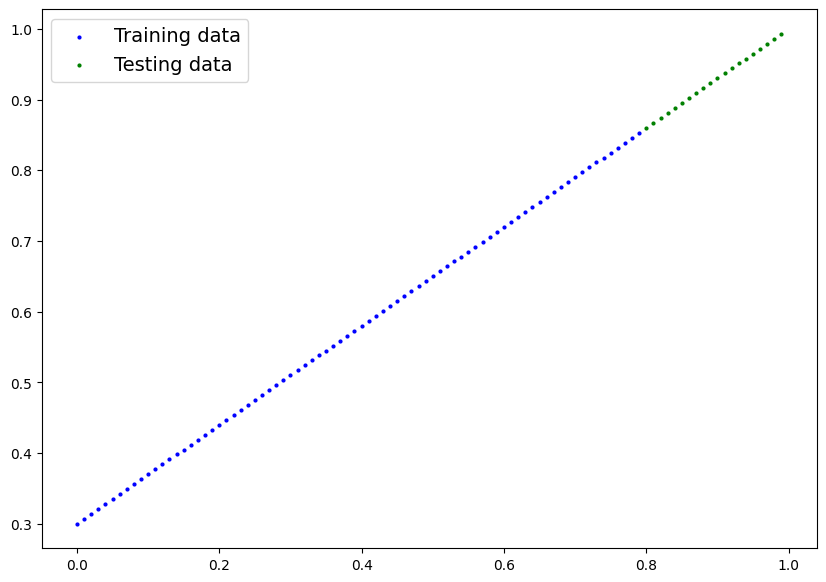

In [37]:
plot_predictions(train_data= X_train_regression, train_labels= y_train_regression, test_data= X_test_regression, test_labels=y_test_regression)

### 5.2 Adjusting `model_1` to fit a straight line

In [38]:
CircleModelV1()

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [39]:
# Same architecture as model_1 (but using nn.Sequential)
model_2= nn.Sequential(nn.Linear(in_features=1, out_features=10), nn.Linear(in_features=10, out_features= 10), nn.Linear(in_features=10, out_features=1)).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [40]:
# Loss and optimizer
loss_fn= nn.L1Loss()
optimizer= torch.optim.SGD(model_2.parameters(), lr= 0.1)

In [41]:
# Training the model
torch.manual_seed(77)

epochs= 1000

# Put the data on the target device
X_train_regression, y_train_regression= X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression= X_test_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):
  model_2.train()
  y_pred= model_2(X_train_regression)
  loss= loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred= model_2(X_test_regression)
    test_loss= loss_fn(test_pred, y_test_regression)

  # Print the details
  if epoch % 100== 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}| Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.79557| Test loss: 0.91613
Epoch: 100 | Loss: 0.10339| Test loss: 0.26900
Epoch: 200 | Loss: 0.06189| Test loss: 0.19837
Epoch: 300 | Loss: 0.05874| Test loss: 0.14165
Epoch: 400 | Loss: 0.06872| Test loss: 0.14826
Epoch: 500 | Loss: 0.06983| Test loss: 0.14575
Epoch: 600 | Loss: 0.06287| Test loss: 0.15037
Epoch: 700 | Loss: 0.05156| Test loss: 0.14371
Epoch: 800 | Loss: 0.05403| Test loss: 0.12935
Epoch: 900 | Loss: 0.07341| Test loss: 0.10676


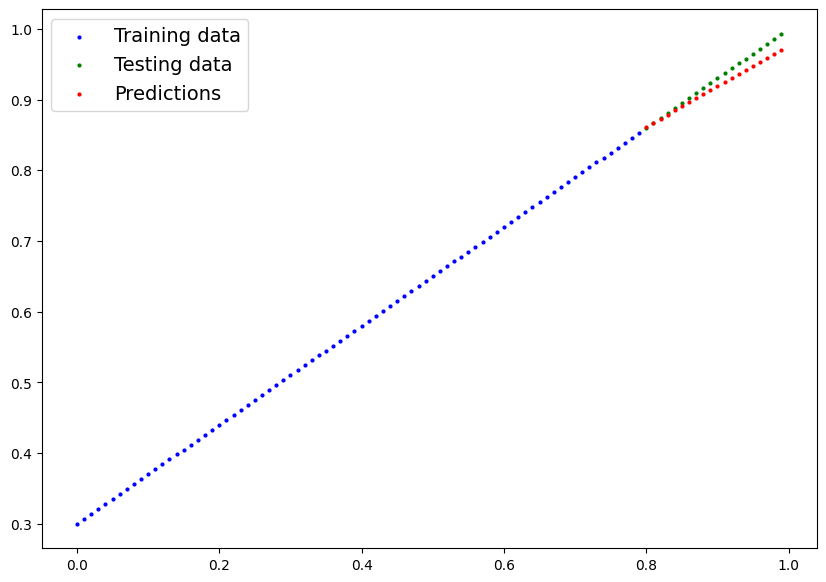

In [42]:
# Turn on eval mode
model_2.eval()

with torch.inference_mode():
  y_preds= model_2(X_test_regression)

# Plot data and predictions
plot_predictions(train_data= X_train_regression.cpu(), train_labels= y_train_regression.cpu(), test_data= X_test_regression.cpu(), test_labels= y_test_regression.cpu(), predictions= y_preds.cpu())

## 6. Non-linearity

### 6.1 Recreating non linear data (red and blue circles)


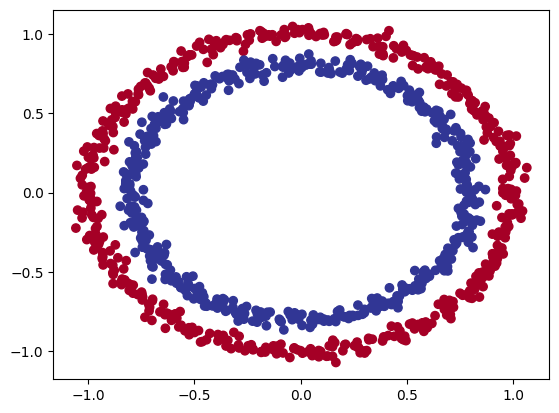

In [43]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples= 1000

X, y= make_circles(n_samples, noise= 0.03, random_state= 77)

plt.scatter(X[:, 0], X[:, 1], c= y, cmap= plt.cm.RdYlBu)

In [44]:
# Converet data to tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X= torch.from_numpy(X).type(torch.float)
y= torch.from_numpy(y).type(torch.float)

# Split data into train and test splits
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 77)

X_train[: 5], y_train[: 5]

(tensor([[ 0.6998, -0.6792],
         [ 0.5844, -0.4890],
         [ 0.6555,  0.4810],
         [ 0.6539, -0.4299],
         [ 0.8856, -0.5251]]),
 tensor([0., 1., 1., 1., 0.]))

In [45]:
### 6.2 Building model with non linear activation function
from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1= nn.Linear(in_features=2, out_features= 10)
    self.layer2= nn.Linear(in_features=10, out_features= 10)
    self.layer3= nn.Linear(in_features=10, out_features= 1)
    self.relu= nn.ReLU()    # non linear activation function

  def forward(self, x):
    return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model_3= CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [46]:
# Setup loss and optimizer
loss_fn= nn.BCEWithLogitsLoss()
optimizer= torch.optim.SGD(model_3.parameters(), lr= 0.1)

### 6.3 Training model with non-linearity

In [47]:
torch.manual_seed(77)

X_train, y_train= X_train.to(device), y_train.to(device)
X_test, y_test= X_test.to(device), y_test.to(device)

epochs= 1000

for epoch in range(epochs):
  model_3.train()

  y_logits= model_3(X_train).squeeze()
  y_pred= torch.round(torch.sigmoid(y_logits))    # logits -> pred prob -> pred labels

  loss= loss_fn(y_logits, y_train)
  acc= accuracy_fn(y_true= y_train, y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()

  optimizer.step()

  # Testing
  model_3.eval()
  with torch.inference_mode():
    test_logits= model_3(X_test).squeeze()
    test_pred= torch.round(torch.sigmoid(test_logits))

    test_loss= loss_fn(test_logits, y_test)
    test_acc= accuracy_fn(y_true= y_test, y_pred= test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69068, Acc: 54.50% | Test loss: 0.69315, Test acc: 52.50%
Epoch: 100 | Loss: 0.68804, Acc: 57.38% | Test loss: 0.69119, Test acc: 53.50%
Epoch: 200 | Loss: 0.68525, Acc: 56.88% | Test loss: 0.68972, Test acc: 52.00%
Epoch: 300 | Loss: 0.68124, Acc: 60.38% | Test loss: 0.68664, Test acc: 59.00%
Epoch: 400 | Loss: 0.67473, Acc: 65.12% | Test loss: 0.68053, Test acc: 60.00%
Epoch: 500 | Loss: 0.66306, Acc: 76.75% | Test loss: 0.66858, Test acc: 70.00%
Epoch: 600 | Loss: 0.64138, Acc: 85.25% | Test loss: 0.64694, Test acc: 81.50%
Epoch: 700 | Loss: 0.60106, Acc: 92.00% | Test loss: 0.60828, Test acc: 90.00%
Epoch: 800 | Loss: 0.52591, Acc: 95.25% | Test loss: 0.53681, Test acc: 94.00%
Epoch: 900 | Loss: 0.40408, Acc: 98.75% | Test loss: 0.42131, Test acc: 98.50%


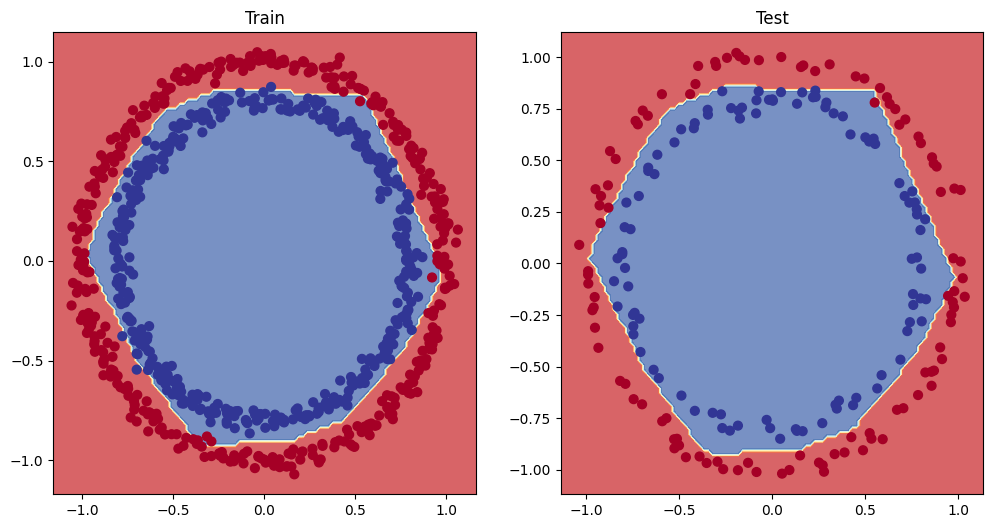

In [48]:
from helper_functions import plot_predictions, plot_decision_boundary

# plot decision boundary of the model
plt.figure(figsize= (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

### 7. Putting it all together with a multi-class classification problem

#### 7.1. Creating a toy multi-class dataset

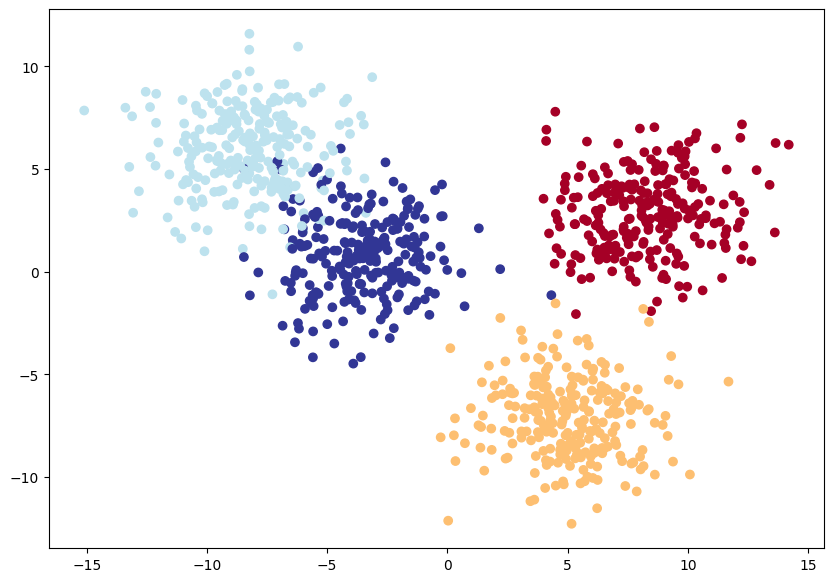

In [49]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES= 4
NUM_FEATURES= 2
RANDOM_SEED= 77

# 1. Create multi-class datea
X_blob, y_blob= make_blobs(n_samples= 1000, n_features= NUM_FEATURES, centers= NUM_CLASSES, cluster_std= 2, random_state= RANDOM_SEED)

# 2. Turn data into tensors
X_blob= torch.from_numpy(X_blob).type(torch.float)
y_blob= torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test= train_test_split(X_blob, y_blob, test_size= 0.2, random_state= RANDOM_SEED)

# 4. Plot data
plt.figure(figsize= (10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c= y_blob, cmap= plt.cm.RdYlBu)

In [50]:
X_blob_train.shape, y_blob_train[: 5]

(torch.Size([800, 2]), tensor([1, 1, 2, 0, 1]))

In [51]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

### 7.2 Building multi-class classification model

In [52]:
# Create device agnostic code
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [53]:

# Building a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units= 8):
    """ Initializing multi class classification model

    Args:
      Input_features (int): Number of input features to the model
      ouput_features (int): Number of output features (Number of output classes)
      hidden_classes (int): Number of hidden unit between layers, default= 8

    Returns:
      Logits (int)
    """
    super().__init__()

    self.linear_layer_stack= nn.Sequential(
        nn.Linear(in_features= input_features, out_features= hidden_units),
        nn.ReLU(),
        nn.Linear(in_features= hidden_units, out_features= hidden_units),
        nn.ReLU(),
        nn.Linear(in_features= hidden_units, out_features= output_features),
        )

  def forward(self, x):
    return self.linear_layer_stack(x)


# Create an instance of BlobModel and send it to the target device
model_4= BlobModel(input_features= 2, output_features= 4, hidden_units= 8).to(device)

model_4


BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 7.3 Create a loss function and optimizer

In [54]:
# Create a loss function
loss_fn= nn.CrossEntropyLoss()

# Create an optimizer
optimizer= torch.optim.SGD(params= model_4.parameters(), lr= 0.1)

### 7.4 Getting prediction probabilites for multi-class classification model

In order to evaluate and train and test the ondel, we need to converet the model
s outputs (logits) to prediction probabilies and then to prediction labels.

Logits -> pred prob -> pred labels

In [55]:
model_4.eval()
with torch.inference_mode():
  y_logits= model_4(X_blob_test.to(device))

y_logits[: 10]

tensor([[-0.6793,  0.0375,  0.1907,  0.3197],
        [-0.6449,  0.0431,  0.1741,  0.2677],
        [-0.8607,  0.1117,  0.4226,  0.2978],
        [-1.0161,  0.1576,  0.5280,  0.3427],
        [-0.0260, -0.2330, -0.1536,  0.1545],
        [ 0.0155, -0.3447, -0.1623,  0.1947],
        [-0.7403,  0.1116,  0.3609,  0.1820],
        [-0.1106, -0.2154,  0.1764,  0.4291],
        [-1.0776,  0.2176,  0.4902,  0.2499],
        [-1.0169,  0.2094,  0.6092,  0.2300]])

In [56]:
y_blob_test[: 10]

tensor([0, 0, 1, 1, 3, 3, 1, 3, 0, 1])

In [57]:
# Convert logits to prediction probabilies
y_pred_probs= torch.softmax(y_logits, dim= 1)

y_pred_probs[: 10]

tensor([[0.1227, 0.2513, 0.2929, 0.3332],
        [0.1291, 0.2568, 0.2927, 0.3214],
        [0.0958, 0.2533, 0.3457, 0.3052],
        [0.0781, 0.2525, 0.3656, 0.3038],
        [0.2570, 0.2090, 0.2262, 0.3078],
        [0.2680, 0.1870, 0.2244, 0.3206],
        [0.1128, 0.2644, 0.3392, 0.2836],
        [0.2021, 0.1820, 0.2693, 0.3467],
        [0.0756, 0.2762, 0.3628, 0.2853],
        [0.0771, 0.2628, 0.3919, 0.2682]])

In [58]:
# Convert the model's prediction probabilites to prediction labels
y_preds= torch.argmax(y_pred_probs, dim= 1)

y_preds

tensor([3, 3, 2, 2, 3, 3, 2, 3, 2, 2, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3,
        3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 2, 2, 2,
        3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 2, 2, 2, 2, 3, 3, 2,
        3, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3,
        2, 3, 3, 3, 3, 3, 3, 2, 2, 3, 2, 2, 3, 2, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 3, 3,
        3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 3, 3, 3, 3, 3, 3, 2, 3,
        3, 2, 3, 2, 2, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        3, 3, 2, 2, 3, 3, 3, 2])

### 7.5 Creating training and testing loop

In [59]:
torch.manual_seed(77)

epochs= 1000

X_blob_train, y_blob_train= X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test= X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
  model_4.train()

  y_logits= model_4(X_blob_train)
  y_pred= torch.softmax(y_logits, dim= 1).argmax(dim= 1)

  loss= loss_fn(y_logits, y_blob_train)
  acc= accuracy_fn(y_true= y_blob_train, y_pred= y_pred)

  optimizer.zero_grad()

  loss.backward()
  optimizer.step()

  # Testing
  model_4.eval()
  with torch.inference_mode():
    test_logits= model_4(X_blob_test)
    test_pred= torch.softmax(test_logits, dim= 1).argmax(dim= 1)

    test_loss= loss_fn(test_logits, y_blob_test)
    acc= accuracy_fn(y_true= y_blob_test, y_pred= test_pred)

  if epoch % 100==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 1.54381, Acc: 53.50% | Test loss: 1.31897, Test acc: 99.50%
Epoch: 100 | Loss: 0.17400, Acc: 96.50% | Test loss: 0.17329, Test acc: 99.50%
Epoch: 200 | Loss: 0.12613, Acc: 97.50% | Test loss: 0.11528, Test acc: 99.50%
Epoch: 300 | Loss: 0.10478, Acc: 97.50% | Test loss: 0.09274, Test acc: 99.50%
Epoch: 400 | Loss: 0.09298, Acc: 98.00% | Test loss: 0.08100, Test acc: 99.50%
Epoch: 500 | Loss: 0.08593, Acc: 98.00% | Test loss: 0.07405, Test acc: 99.50%
Epoch: 600 | Loss: 0.08141, Acc: 98.00% | Test loss: 0.06969, Test acc: 99.50%
Epoch: 700 | Loss: 0.07838, Acc: 98.00% | Test loss: 0.06683, Test acc: 99.50%
Epoch: 800 | Loss: 0.07631, Acc: 97.50% | Test loss: 0.06487, Test acc: 99.50%
Epoch: 900 | Loss: 0.07484, Acc: 97.50% | Test loss: 0.06354, Test acc: 99.50%


### 7.4 Making and evaluating predictions


In [60]:
# Make predictions
model_4.eval()
with torch.inference_mode():
  y_logits= model_4(X_blob_test)

y_logits[: 10]

tensor([[ 6.5343, -2.6642, -4.0933, -1.3921],
        [ 5.8593, -1.9668, -4.1173, -1.2358],
        [-6.6611, 11.3240, -2.6440,  1.1541],
        [-8.0640, 13.6163, -2.6163,  0.8355],
        [-1.5565,  0.3578, -2.0605,  4.1854],
        [-3.2492, -3.8535,  4.2272,  7.4301],
        [-0.8693,  5.3945, -3.4711,  0.1459],
        [-4.5017, -5.6756,  8.5400,  8.1362],
        [ 5.1384,  1.8129, -5.0049, -2.7782],
        [-5.3191, 11.7381, -3.2641, -0.0565]])

In [61]:
test_pred_probs= torch.softmax(test_logits, dim= 1).argmax(dim= 1)

In [62]:
y_preds= torch.argmax(y_pred_probs, dim= 1)

y_preds

tensor([3, 3, 2, 2, 3, 3, 2, 3, 2, 2, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3,
        3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 2, 2, 2,
        3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 2, 2, 2, 2, 3, 3, 2,
        3, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3,
        2, 3, 3, 3, 3, 3, 3, 2, 2, 3, 2, 2, 3, 2, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 3, 3,
        3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 3, 3, 3, 3, 3, 3, 2, 3,
        3, 2, 3, 2, 2, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        3, 3, 2, 2, 3, 3, 3, 2])

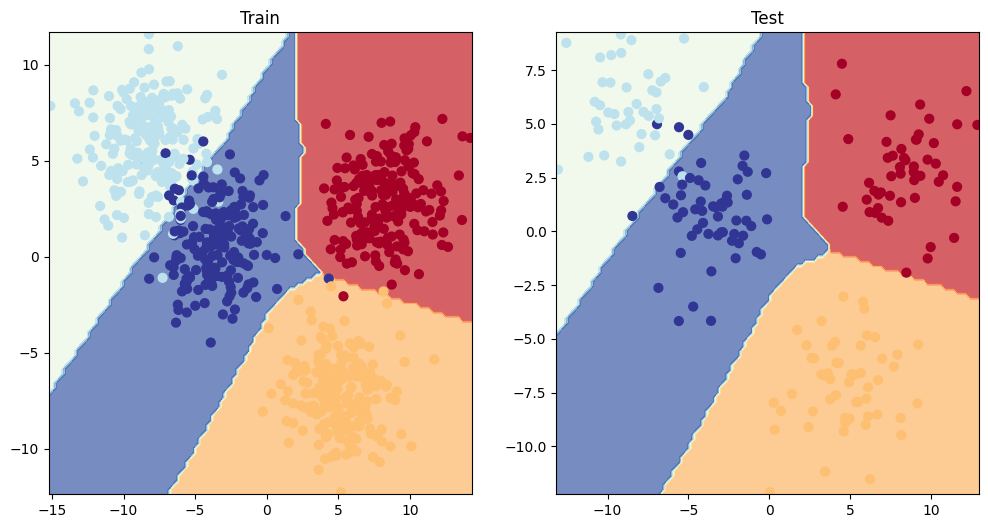

In [63]:
from helper_functions import plot_predictions, plot_decision_boundary

# plot decision boundary of the model
plt.figure(figsize= (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 8. Evaluating the model

1. Accuracy
2. Precision
3. Recall
4. F1- score
5. Confusion matrix
6. Classification report

In [64]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.3 MB/s eta 0:00:00


In [65]:
from torchmetrics import Accuracy

acc= Accuracy(task='multiclass', num_classes= NUM_CLASSES).to(device)

acc(test_pred, y_blob_test)

tensor(0.9750)